In [1]:
import os
DATASET_PATH = "/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed"

patients = sorted(os.listdir(DATASET_PATH))

print("Nombre de patients :", len(patients))
print(patients[:5])
patient = patients[0]

print(os.listdir(os.path.join(DATASET_PATH, patient)))

Nombre de patients : 240
['sub-strokecase0001', 'sub-strokecase0002', 'sub-strokecase0003', 'sub-strokecase0004', 'sub-strokecase0006']
['flair.npy', 'adc.npy', 'dwi.npy', 'mask.npy']


In [2]:
import numpy as np
import os

DATASET_PATH = "/kaggle/input/datasets/hazemhadda/stroke-isles-2022-processed/preprocessed"

patient = "sub-strokecase0001"
patient_path = os.path.join(DATASET_PATH, patient)

for file in ["flair.npy", "adc.npy", "dwi.npy", "mask.npy"]:
    data = np.load(os.path.join(patient_path, file))
    print(f"{file}")
    print(f"Shape : {data.shape}")
    print(f"Dtype : {data.dtype}")
    print("-" * 40)

flair.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
adc.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
dwi.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------
mask.npy
Shape : (128, 128, 64)
Dtype : float32
----------------------------------------


### Import Libraries

In [3]:
!pip install -q monai nibabel SimpleITK mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 707.2 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 7.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 50.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 90.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [4]:
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric, MeanIoU
from monai.transforms import Compose, Activations, AsDiscrete, RandFlipd, RandRotate90d
from monai.data import decollate_batch

In [5]:
MLFLOW_TRACKING_URI = "https://elated-autistic-subfloor.ngrok-free.dev"
EXPERIMENT_NAME = "Stroke-Segmentation"

In [6]:
SAVE_DIR = Path("/kaggle/working/models/unet3d_flair")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    client = mlflow.MlflowClient()
    client.search_experiments()  # ping simple pour tester la connexion
    print(f"Connexion réussie au serveur MLflow : {MLFLOW_TRACKING_URI}")
except Exception as e:
    print(f"Impossible de se connecter au serveur MLflow ({MLFLOW_TRACKING_URI})")
    print(f"Erreur : {e}")

mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Experiment actif : {EXPERIMENT_NAME}")

Connexion réussie au serveur MLflow : https://elated-autistic-subfloor.ngrok-free.dev
Experiment actif : Stroke-Segmentation


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print(f"PyTorch Version : {torch.__version__}")
print(f"MONAI Version   : {__import__('monai').__version__}")
print(f"Device          : {device}")
print("=" * 50)

PyTorch Version : 2.10.0+cu128
MONAI Version   : 1.6.0
Device          : cuda


### Création du StrokeDataset

In [9]:
class StrokeDatasetFLAIR(Dataset):

    def __init__(self, patient_dirs):
        self.patient_dirs = patient_dirs

    def __len__(self):
        return len(self.patient_dirs)

    def __getitem__(self, index):

        patient_dir = self.patient_dirs[index]

        # Charger uniquement la modalité FLAIR
        flair = np.load(patient_dir / "flair.npy").astype(np.float32)

        # Normalisation Z-score
        if flair.std() > 0:
            flair = (flair - flair.mean()) / flair.std()

        # Charger le masque
        mask = np.load(patient_dir / "mask.npy").astype(np.float32)

        # Ajouter la dimension du canal
        image = np.expand_dims(flair, axis=0)
        mask = np.expand_dims(mask, axis=0)

        # Conversion en tenseurs PyTorch
        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).float()

        return image, mask

### Créer les DataLoader

In [10]:
from sklearn.model_selection import train_test_split

# Récupérer tous les dossiers patients
patients = sorted([
    Path(DATASET_PATH) / p
    for p in os.listdir(DATASET_PATH)
    if os.path.isdir(Path(DATASET_PATH) / p)
])

print("Nombre total de patients :", len(patients))

train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.20,
    random_state=42,
    shuffle=True
)


val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("=" * 50)
print("Patient split")
print("=" * 50)
print(f"Train      : {len(train_patients)} patients")
print(f"Validation : {len(val_patients)} patients")
print(f"Test       : {len(test_patients)} patients")
print(f"Total      : {len(train_patients) + len(val_patients) + len(test_patients)}")

Nombre total de patients : 240
Patient split
Train      : 192 patients
Validation : 24 patients
Test       : 24 patients
Total      : 240


In [11]:
train_dataset = StrokeDatasetFLAIR(train_patients)
val_dataset = StrokeDatasetFLAIR(val_patients)
test_dataset = StrokeDatasetFLAIR(test_patients)


train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches      : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches       : {len(test_loader)}")

Train batches      : 192
Validation batches : 24
Test batches       : 24


### Définir la Loss et l'Optimizer et Hyperparameters

In [12]:
from torch.optim import Adam

# Loss
loss_function = DiceCELoss(
    sigmoid=True,
    squared_pred=True,
    reduction="mean",
    lambda_ce=0.5,
    lambda_dice=1.5
)

# Metrics
dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

iou_metric = MeanIoU(
    include_background=False,
    reduction="mean"
)

# Experiments
experiments = [

    {
        "name": "FLAIR_3D_Adam_lr5e4",
        "optimizer": Adam,
        "optimizer_name": "Adam",
        "lr": 5e-4
    },

    {
        "name": "FLAIR_3D_Adam_lr1e3",
        "optimizer": Adam,
        "optimizer_name": "Adam",
        "lr": 1e-3
    }
]

print(
    "Loss Function :",
    loss_function
)

print(
    "Experiments :",
    [exp["name"] for exp in experiments]
)

Loss Function : DiceCELoss(
  (dice): DiceLoss()
  (cross_entropy): CrossEntropyLoss()
  (binary_cross_entropy): BCEWithLogitsLoss()
)
Experiments : ['FLAIR_3D_Adam_lr5e4', 'FLAIR_3D_Adam_lr1e3']


### Post-processing

In [13]:
# Post-processing for predictions

post_pred = Compose([
    Activations(sigmoid=True),
    AsDiscrete(threshold=0.5)
])

### Initialisation des paramètres

In [14]:
num_epochs = 100


results = []


FLAIR_SAVE_DIR = os.path.join(
    SAVE_DIR,
    "flair_3d"
)


os.makedirs(
    FLAIR_SAVE_DIR,
    exist_ok=True
)

### Fonction d'entraînement

In [15]:
def train_one_epoch(model, train_loader, optimizer, loss_function, device):

    model.train()

    epoch_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, masks)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(train_loader)

### Fonction de validation

In [16]:
from monai.metrics import MeanIoU

def validate(model, val_loader, dice_metric, iou_metric, post_pred, device):

    model.eval()

    dice_metric.reset()
    iou_metric.reset()

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            outputs = [
                post_pred(i)
                for i in decollate_batch(outputs)
            ]

            masks = decollate_batch(masks)

            dice_metric(
                y_pred=outputs,
                y=masks
            )

            iou_metric(
                y_pred=outputs,
                y=masks
            )

    dice = dice_metric.aggregate().item()
    iou = iou_metric.aggregate().item()

    dice_metric.reset()
    iou_metric.reset()

    return dice, iou

### Expériences


Running experiment: FLAIR-3D_FLAIR_3D_Adam_lr5e4
Epoch [001/100] | Loss: 1.6864 | Dice: 0.0888 | IoU: 0.0528
Epoch [002/100] | Loss: 1.4420 | Dice: 0.2407 | IoU: 0.1620
Epoch [003/100] | Loss: 1.2566 | Dice: 0.2897 | IoU: 0.2032
Epoch [004/100] | Loss: 1.1274 | Dice: 0.2578 | IoU: 0.1819
Epoch [005/100] | Loss: 1.0773 | Dice: 0.1826 | IoU: 0.1139
Epoch [006/100] | Loss: 1.0466 | Dice: 0.3559 | IoU: 0.2494
Epoch [007/100] | Loss: 1.0065 | Dice: 0.3764 | IoU: 0.2680
Epoch [008/100] | Loss: 0.9687 | Dice: 0.2304 | IoU: 0.1495
Epoch [009/100] | Loss: 0.9742 | Dice: 0.3795 | IoU: 0.2677
Epoch [010/100] | Loss: 0.9432 | Dice: 0.3907 | IoU: 0.2779
Epoch [011/100] | Loss: 0.9027 | Dice: 0.3762 | IoU: 0.2659
Epoch [012/100] | Loss: 0.8871 | Dice: 0.3719 | IoU: 0.2608
Epoch [013/100] | Loss: 0.8824 | Dice: 0.3412 | IoU: 0.2405
Epoch [014/100] | Loss: 0.8786 | Dice: 0.3520 | IoU: 0.2496
Epoch [015/100] | Loss: 0.8388 | Dice: 0.3097 | IoU: 0.2209
Epoch [016/100] | Loss: 0.8169 | Dice: 0.3303 | Io

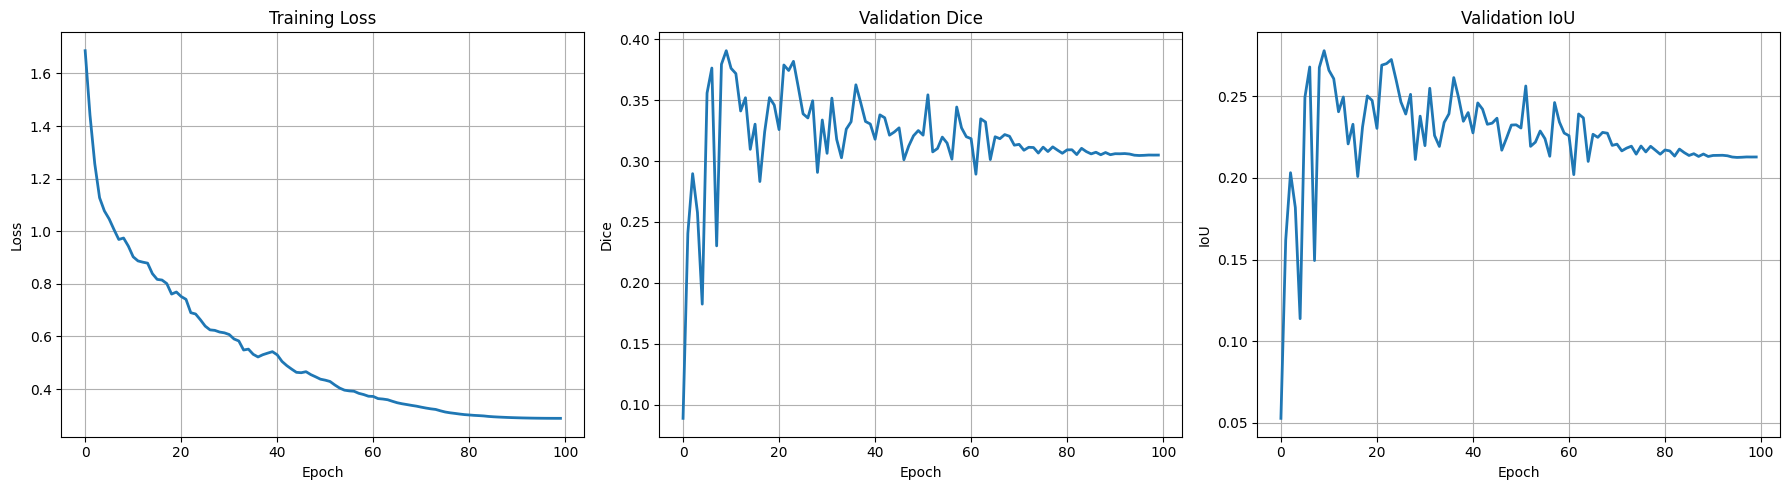

🏃 View run FLAIR-3D_FLAIR_3D_Adam_lr5e4 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/3d6fd8305e9c4f7eaaed9c497d840381
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1

[FIN] FLAIR_3D_Adam_lr5e4 -> Best Dice: 0.3907 | Best IoU: 0.2779 | Run ID: 3d6fd8305e9c4f7eaaed9c497d840381

Running experiment: FLAIR-3D_FLAIR_3D_Adam_lr1e3
Epoch [001/100] | Loss: 1.6630 | Dice: 0.1260 | IoU: 0.0754
Epoch [002/100] | Loss: 1.2779 | Dice: 0.2441 | IoU: 0.1666
Epoch [003/100] | Loss: 1.1278 | Dice: 0.2377 | IoU: 0.1551
Epoch [004/100] | Loss: 1.0839 | Dice: 0.3156 | IoU: 0.2183
Epoch [005/100] | Loss: 1.0322 | Dice: 0.2264 | IoU: 0.1466
Epoch [006/100] | Loss: 1.0462 | Dice: 0.3504 | IoU: 0.2447
Epoch [007/100] | Loss: 1.0076 | Dice: 0.3635 | IoU: 0.2557
Epoch [008/100] | Loss: 0.9728 | Dice: 0.3430 | IoU: 0.2391
Epoch [009/100] | Loss: 0.9921 | Dice: 0.2995 | IoU: 0.2041
Epoch [010/100] | Loss: 0.9616 | Dice: 0.3463 | IoU: 0.2470
Epoch [0

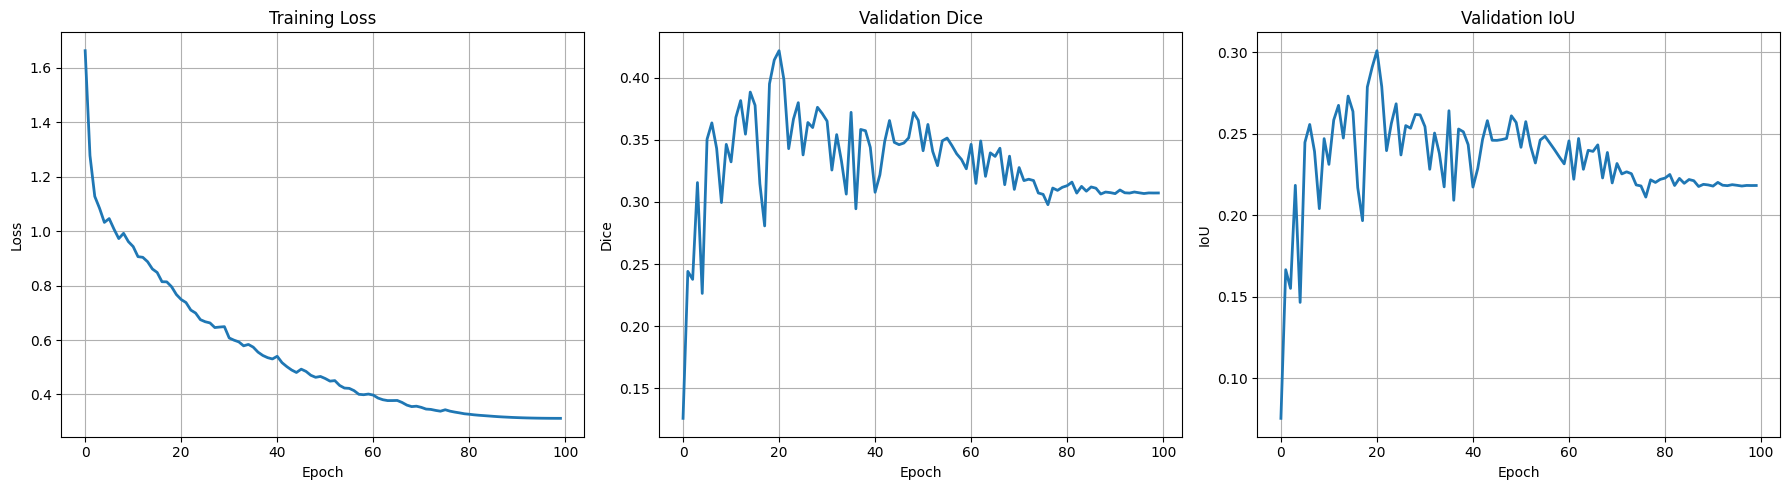

🏃 View run FLAIR-3D_FLAIR_3D_Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/f081276c88144d239088f8aa99a1b2f1
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1

[FIN] FLAIR_3D_Adam_lr1e3 -> Best Dice: 0.4216 | Best IoU: 0.3009 | Run ID: f081276c88144d239088f8aa99a1b2f1

FLAIR-3D Training completed successfully.


In [17]:
results = []

for exp in experiments:

    print("\n" + "=" * 60)

    print(
        f"Running experiment: "
        f"FLAIR-3D_{exp['name']}"
    )

    print("=" * 60)

    # Start MLflow Run

    with mlflow.start_run(
        run_name=f"FLAIR-3D_{exp['name']}"
    ) as run:

        # Tags

        mlflow.set_tag(
            "experiment_group",
            "FLAIR-3D"
        )

        mlflow.set_tag(
            "modality",
            "FLAIR"
        )

        mlflow.set_tag(
            "dimension",
            "3D"
        )

        mlflow.set_tag(
            "Dataset",
            "ISLES2022"
        )

        mlflow.set_tag(
            "framework",
            "PyTorch + MONAI"
        )

        # Parameters

        mlflow.log_param(
            "architecture",
            "3D U-Net"
        )

        mlflow.log_param(
            "model",
            "3D_UNet"
        )

        mlflow.log_param(
            "modality",
            "FLAIR"
        )

        mlflow.log_param(
            "dimension",
            "3D"
        )

        mlflow.log_param(
            "optimizer",
            exp["optimizer_name"]
        )

        mlflow.log_param(
            "learning_rate",
            exp["lr"]
        )

        mlflow.log_param(
            "batch_size",
            1
        )

        mlflow.log_param(
            "epochs",
            num_epochs
        )

        mlflow.log_param(
            "num_channels",
            1
        )

        mlflow.log_param(
            "input_modality",
            "FLAIR"
        )

        mlflow.log_param(
            "channels",
            str((16, 32, 64, 128, 256))
        )

        mlflow.log_param(
            "strides",
            str((2, 2, 2, 2))
        )

        mlflow.log_param(
            "num_res_units",
            2
        )

        mlflow.log_param(
            "scheduler",
            "CosineAnnealingLR"
        )

        mlflow.log_param(
            "loss_function",
            "DiceCELoss"
        )

        mlflow.log_param(
            "lambda_dice",
            1.5
        )

        mlflow.log_param(
            "lambda_ce",
            0.5
        )

        # Model

        model = UNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=1,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
        ).to(device)

        # Optimizer

        optimizer = exp["optimizer"](
            model.parameters(),
            lr=exp["lr"]
        )

        # Scheduler

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )

        # Best Model

        best_dice = 0.0
        best_iou = 0.0
        best_epoch = 0

        train_losses = []
        val_dices = []
        val_ious = []

        model_path = os.path.join(
            FLAIR_SAVE_DIR,
            f"best_model_{exp['name']}.pth"
        )

        # Training

        for epoch in range(num_epochs):

            epoch_loss = train_one_epoch(
                model=model,
                train_loader=train_loader,
                optimizer=optimizer,
                loss_function=loss_function,
                device=device
            )

            train_losses.append(
                epoch_loss
            )

            # Validation

            dice, iou = validate(
                model=model,
                val_loader=val_loader,
                dice_metric=dice_metric,
                iou_metric=iou_metric,
                post_pred=post_pred,
                device=device
            )

            val_dices.append(dice)
            val_ious.append(iou)

            scheduler.step()

            # Log Epoch Metrics

            mlflow.log_metric(
                "train_loss",
                epoch_loss,
                step=epoch + 1
            )

            mlflow.log_metric(
                "val_dice",
                dice,
                step=epoch + 1
            )

            mlflow.log_metric(
                "val_iou",
                iou,
                step=epoch + 1
            )

            # Best Model

            if dice > best_dice:

                best_dice = dice
                best_iou = iou
                best_epoch = epoch + 1

                torch.save(
                    model.state_dict(),
                    model_path
                )

            print(
                f"Epoch [{epoch + 1:03d}/{num_epochs}] "
                f"| Loss: {epoch_loss:.4f} "
                f"| Dice: {dice:.4f} "
                f"| IoU: {iou:.4f}"
            )

        # Best Metrics

        mlflow.log_metric(
            "best_dice",
            best_dice
        )

        mlflow.log_metric(
            "best_iou",
            best_iou
        )

        mlflow.log_metric(
            "best_epoch",
            best_epoch
        )

        # Log Model

        mlflow.log_artifact(
            model_path,
            artifact_path="model"
        )

        # Training Curves

        curve_path = os.path.join(
            FLAIR_SAVE_DIR,
            f"training_curves_{exp['name']}.png"
        )

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(18, 5)
        )

        axes[0].plot(
            train_losses,
            linewidth=2
        )

        axes[0].set_title(
            "Training Loss"
        )

        axes[0].set_xlabel(
            "Epoch"
        )

        axes[0].set_ylabel(
            "Loss"
        )

        axes[0].grid(True)

        axes[1].plot(
            val_dices,
            linewidth=2
        )

        axes[1].set_title(
            "Validation Dice"
        )

        axes[1].set_xlabel(
            "Epoch"
        )

        axes[1].set_ylabel(
            "Dice"
        )

        axes[1].grid(True)

        axes[2].plot(
            val_ious,
            linewidth=2
        )

        axes[2].set_title(
            "Validation IoU"
        )

        axes[2].set_xlabel(
            "Epoch"
        )

        axes[2].set_ylabel(
            "IoU"
        )

        axes[2].grid(True)

        plt.tight_layout()

        plt.savefig(
            curve_path,
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()

        plt.close(fig)

        # Log Curves

        mlflow.log_artifact(
            curve_path,
            artifact_path="plots"
        )

        run_id = run.info.run_id

    # Save Python Results

    results.append({

        "Experiment":
            exp["name"],

        "Run Name":
            f"FLAIR-3D_{exp['name']}",

        "Run ID":
            run_id,

        "Learning Rate":
            exp["lr"],

        "Best Dice":
            best_dice,

        "Best IoU":
            best_iou,

        "Best Epoch":
            best_epoch,

        "Train Loss":
            train_losses,

        "Validation Dice":
            val_dices,

        "Validation IoU":
            val_ious,

        "Model Path":
            model_path
    })

    print(
        f"\n[FIN] {exp['name']} "
        f"-> Best Dice: {best_dice:.4f} "
        f"| Best IoU: {best_iou:.4f} "
        f"| Run ID: {run_id}"
    )

print(
    "\nFLAIR-3D Training completed successfully."
)

In [18]:
print(dice_metric)
print(iou_metric)

DiceMetric
MeanIoU


### Comparaison des expériences

In [19]:
df_results = pd.DataFrame(
    results
)


df_results = df_results.sort_values(
    by="Best Dice",
    ascending=False
).reset_index(drop=True)


comparison_columns = [
    "Run Name",
    "Run ID",
    "Learning Rate",
    "Best Dice",
    "Best IoU",
    "Best Epoch",
    "Model Path"
]


print("=" * 80)
print("Comparison of FLAIR-3D Experiments")
print("=" * 80)


display(
    df_results[comparison_columns]
)

Comparison of FLAIR-3D Experiments


,Run Name,Run ID,Learning Rate,Best Dice,Best IoU,Best Epoch,Model Path
0,FLAIR-3D_FLAIR_3D_Adam_lr1e3,f081276c88144d239088f8aa99a1b2f1,0.0010,0.421597,0.300917,21,/kaggle/working/models/unet3d_flair/flair_3d/b...
1,FLAIR-3D_FLAIR_3D_Adam_lr5e4,3d6fd8305e9c4f7eaaed9c497d840381,0.0005,0.390662,0.277913,10,/kaggle/working/models/unet3d_flair/flair_3d/b...


### Tracer les courbes de Loss et du Dice

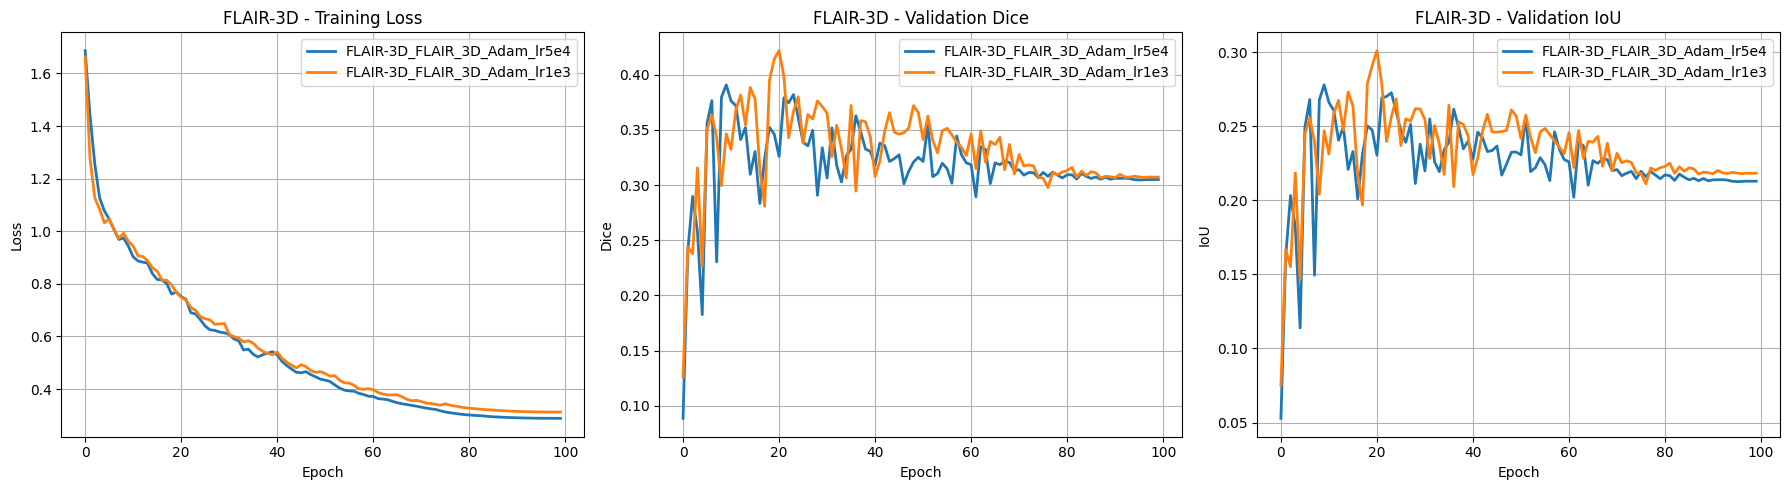

In [20]:
plt.figure(
    figsize=(18, 5)
)

plt.subplot(1, 3, 1)

for result in results:

    plt.plot(
        result["Train Loss"],
        linewidth=2,
        label=result["Run Name"]
    )

plt.title(
    "FLAIR-3D - Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)

for result in results:

    plt.plot(
        result["Validation Dice"],
        linewidth=2,
        label=result["Run Name"]
    )

plt.title(
    "FLAIR-3D - Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice")

plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)

for result in results:

    plt.plot(
        result["Validation IoU"],
        linewidth=2,
        label=result["Run Name"]
    )

plt.title(
    "FLAIR-3D - Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")

plt.grid(True)
plt.legend()

plt.tight_layout()

comparison_curve_path = os.path.join(
    FLAIR_SAVE_DIR,
    "comparison_training_curves.png"
)

plt.savefig(
    comparison_curve_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Visualiser la prédiction du meilleur modèle

Best Run Name : FLAIR-3D_FLAIR_3D_Adam_lr1e3
Best Dice     : 0.4216
Best IoU      : 0.3009
Best Epoch    : 21
Run ID        : f081276c88144d239088f8aa99a1b2f1
Model Path    : /kaggle/working/models/unet3d_flair/flair_3d/best_model_FLAIR_3D_Adam_lr1e3.pth
Best FLAIR-3D model loaded successfully.


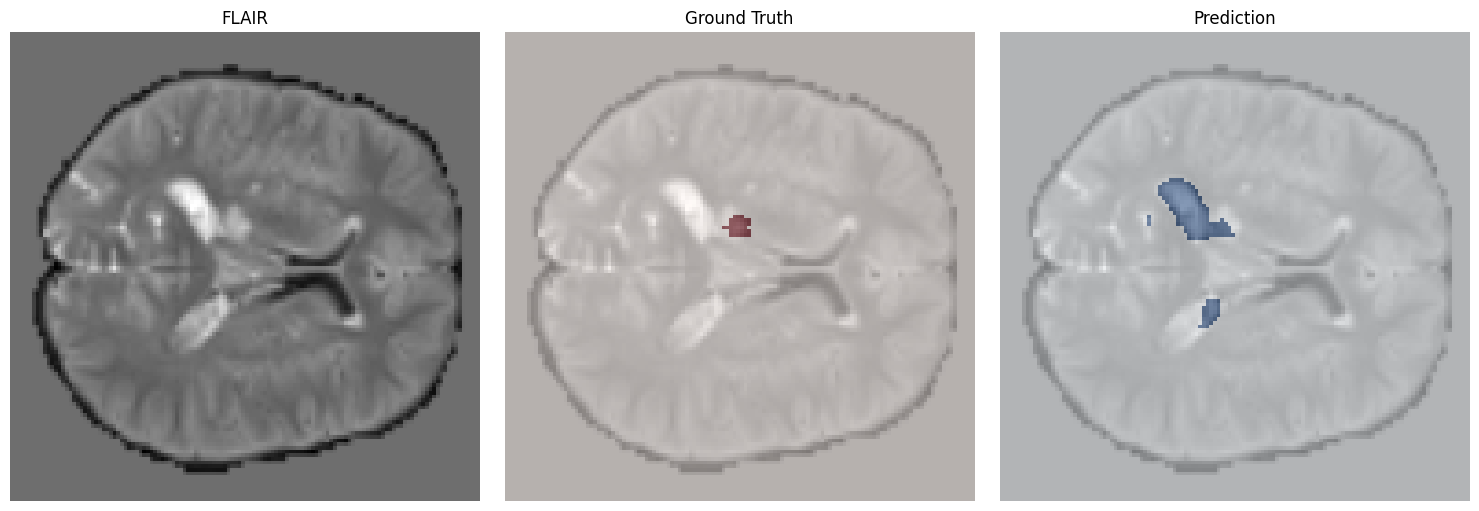

🏃 View run FLAIR-3D_FLAIR_3D_Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/f081276c88144d239088f8aa99a1b2f1
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
FLAIR-3D segmentation visualization logged to the best MLflow Run.


In [21]:
# ==========================================================
# Select and Load the Best FLAIR-3D Model
# ==========================================================

best_result = max(
    results,
    key=lambda x: x["Best Dice"]
)

print("=" * 60)

print(
    "Best Run Name :",
    best_result["Run Name"]
)

print(
    "Best Dice     :",
    f"{best_result['Best Dice']:.4f}"
)

print(
    "Best IoU      :",
    f"{best_result['Best IoU']:.4f}"
)

print(
    "Best Epoch    :",
    best_result["Best Epoch"]
)

print(
    "Run ID        :",
    best_result["Run ID"]
)

print(
    "Model Path    :",
    best_result["Model Path"]
)

print("=" * 60)


# ==========================================================
# Recreate Best FLAIR-3D Model
# ==========================================================

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)


# ==========================================================
# Load Best Model Weights
# ==========================================================

model.load_state_dict(
    torch.load(
        best_result["Model Path"],
        map_location=device
    )
)

model.eval()

print(
    "Best FLAIR-3D model loaded successfully."
)


# ==========================================================
# Generate Segmentation Visualization
# ==========================================================

segmentation_visualization_path = os.path.join(
    FLAIR_SAVE_DIR,
    "segmentation_visualization.png"
)


# ----------------------------------------------------------
# Load One Test Sample
# ----------------------------------------------------------

images, masks = next(
    iter(test_loader)
)

images = images.to(device)
masks = masks.to(device)


# ----------------------------------------------------------
# Prediction
# ----------------------------------------------------------

with torch.no_grad():

    outputs = model(images)

    predictions = (
        torch.sigmoid(outputs) > 0.5
    ).float()


# ----------------------------------------------------------
# Select Middle Slice
# ----------------------------------------------------------

slice_idx = images.shape[-1] // 2

flair = (
    images[0, 0, :, :, slice_idx]
    .cpu()
    .numpy()
)

ground_truth = (
    masks[0, 0, :, :, slice_idx]
    .cpu()
    .numpy()
)

prediction = (
    predictions[0, 0, :, :, slice_idx]
    .cpu()
    .numpy()
)


# ==========================================================
# Plot FLAIR / Ground Truth / Prediction
# ==========================================================

plt.figure(
    figsize=(15, 5)
)


# ----------------------------------------------------------
# FLAIR
# ----------------------------------------------------------

plt.subplot(1, 3, 1)

plt.imshow(
    flair,
    cmap="gray"
)

plt.title(
    "FLAIR"
)

plt.axis("off")


# ----------------------------------------------------------
# Ground Truth
# ----------------------------------------------------------

plt.subplot(1, 3, 2)

plt.imshow(
    flair,
    cmap="gray"
)

plt.imshow(
    ground_truth,
    cmap="Reds",
    alpha=0.5
)

plt.title(
    "Ground Truth"
)

plt.axis("off")


# ----------------------------------------------------------
# Prediction
# ----------------------------------------------------------

plt.subplot(1, 3, 3)

plt.imshow(
    flair,
    cmap="gray"
)

plt.imshow(
    prediction,
    cmap="Blues",
    alpha=0.5
)

plt.title(
    "Prediction"
)

plt.axis("off")


plt.tight_layout()


# ==========================================================
# Save Visualization
# ==========================================================

plt.savefig(
    segmentation_visualization_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ==========================================================
# Log Visualization to the Best MLflow Run
# ==========================================================

with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_artifact(
        segmentation_visualization_path,
        artifact_path="predictions"
    )


print(
    "FLAIR-3D segmentation visualization "
    "logged to the best MLflow Run."
)

### evalue le model (precision_score....)

In [22]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

model.eval()

dice_metric.reset()

ious = []

all_preds = []
all_masks = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        preds = (
            torch.sigmoid(outputs) > 0.5
        ).float()

        # ==================================================
        # Dice
        # ==================================================

        dice_metric(
            y_pred=preds,
            y=masks
        )

        # ==================================================
        # IoU
        # ==================================================

        intersection = (
            preds * masks
        ).sum().item()

        union = (
            preds.sum().item()
            + masks.sum().item()
            - intersection
        )

        iou = (
            intersection + 1e-6
        ) / (
            union + 1e-6
        )

        ious.append(iou)

        # ==================================================
        # Store predictions
        # ==================================================

        all_preds.extend(
            preds.cpu().numpy().flatten()
        )

        all_masks.extend(
            masks.cpu().numpy().flatten()
        )


# ==========================================================
# Dice / IoU
# ==========================================================

dice = dice_metric.aggregate().item()

mean_iou = np.mean(ious)

dice_metric.reset()


# ==========================================================
# Precision / Recall / F1
# ==========================================================

all_preds = np.array(
    all_preds
).astype(np.uint8)

all_masks = np.array(
    all_masks
).astype(np.uint8)

precision = precision_score(
    all_masks,
    all_preds,
    zero_division=0
)

recall = recall_score(
    all_masks,
    all_preds,
    zero_division=0
)

f1 = f1_score(
    all_masks,
    all_preds,
    zero_division=0
)


# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    all_masks,
    all_preds
)

tn, fp, fn, tp = cm.ravel()


# ==========================================================
# Display
# ==========================================================

metrics_df = pd.DataFrame({

    "Metric": [
        "Dice",
        "IoU",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Value": [
        dice,
        mean_iou,
        precision,
        recall,
        f1
    ]
})

print("=" * 60)
print("FLAIR-3D - Test Set Evaluation")
print("=" * 60)

display(metrics_df)

print("\nConfusion Matrix")
print(cm)

print(
    f"\nTP : {tp}"
)

print(
    f"TN : {tn}"
)

print(
    f"FP : {fp}"
)

print(
    f"FN : {fn}"
)


# ==========================================================
# Log Test Metrics to Best Run
# ==========================================================

with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_metric(
        "test_dice",
        dice
    )

    mlflow.log_metric(
        "test_iou",
        mean_iou
    )

    mlflow.log_metric(
        "test_precision",
        precision
    )

    mlflow.log_metric(
        "test_recall",
        recall
    )

    mlflow.log_metric(
        "test_f1",
        f1
    )


print(
    "\nFLAIR-3D test metrics logged to MLflow."
)

FLAIR-3D - Test Set Evaluation


,Metric,Value
0,Dice,0.428767
1,IoU,0.298984
2,Precision,0.620238
3,Recall,0.648221
4,F1-score,0.633921



Confusion Matrix
[[25004294    45895]
 [   40678    74957]]

TP : 74957
TN : 25004294
FP : 45895
FN : 40678
🏃 View run FLAIR-3D_FLAIR_3D_Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/f081276c88144d239088f8aa99a1b2f1
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1

FLAIR-3D test metrics logged to MLflow.


### Confusion Matrix

<Figure size 600x600 with 0 Axes>

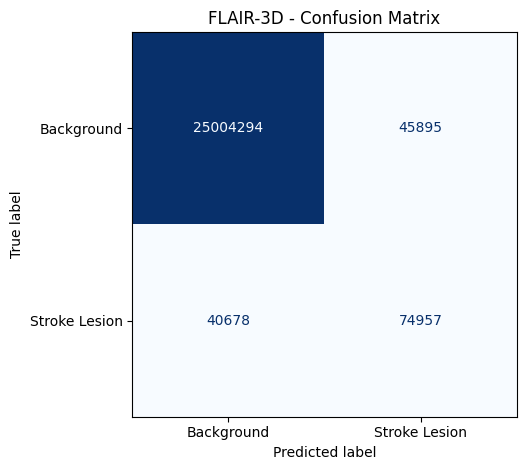

🏃 View run FLAIR-3D_FLAIR_3D_Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/f081276c88144d239088f8aa99a1b2f1
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
FLAIR-3D confusion matrix logged to MLflow.


In [23]:
# ==========================================================
# FLAIR-3D - Confusion Matrix
# ==========================================================

plt.figure(
    figsize=(6, 6)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Background",
        "Stroke Lesion"
    ]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    "FLAIR-3D - Confusion Matrix"
)

plt.grid(False)

plt.tight_layout()


# ==========================================================
# Save
# ==========================================================

confusion_matrix_path = os.path.join(
    FLAIR_SAVE_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ==========================================================
# Log Artifact
# ==========================================================

with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_artifact(
        confusion_matrix_path,
        artifact_path="evaluation"
    )


print(
    "FLAIR-3D confusion matrix logged to MLflow."
)

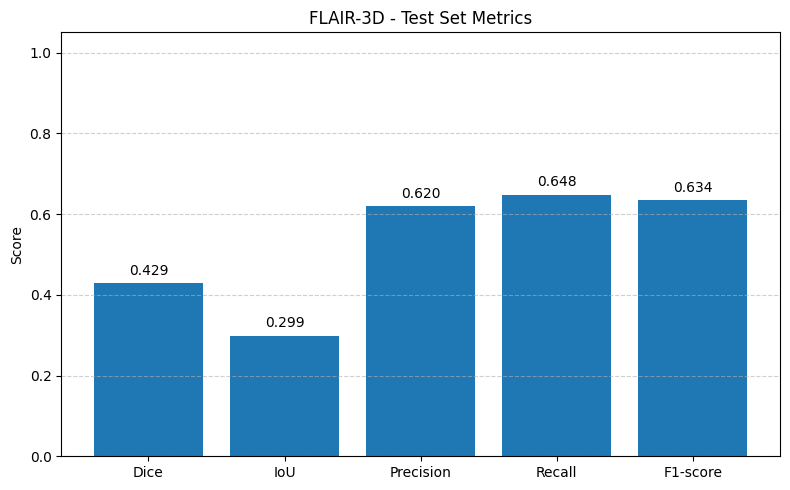

🏃 View run FLAIR-3D_FLAIR_3D_Adam_lr1e3 at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1/runs/f081276c88144d239088f8aa99a1b2f1
🧪 View experiment at: https://elated-autistic-subfloor.ngrok-free.dev/#/experiments/1
FLAIR-3D test metrics plot logged to MLflow.


In [24]:
# ==========================================================
# FLAIR-3D - Test Metrics Plot
# ==========================================================

metrics = [
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "F1-score"
]

values = [
    dice,
    mean_iou,
    precision,
    recall,
    f1
]

plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    metrics,
    values
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "Score"
)

plt.title(
    "FLAIR-3D - Test Set Metrics"
)

for bar, value in zip(
    bars,
    values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        fontsize=10
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()


# ==========================================================
# Save
# ==========================================================

test_metrics_path = os.path.join(
    FLAIR_SAVE_DIR,
    "test_metrics.png"
)

plt.savefig(
    test_metrics_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ==========================================================
# Log Artifact
# ==========================================================

with mlflow.start_run(
    run_id=best_result["Run ID"]
):

    mlflow.log_artifact(
        test_metrics_path,
        artifact_path="evaluation"
    )

print(
    "FLAIR-3D test metrics plot logged to MLflow."
)

### Evaluation Metrics Table

In [25]:
# Evaluation Metrics Table

metrics_df = pd.DataFrame({
    "Metric": [
        "Dice",
        "IoU",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value": [
        dice,
        mean_iou,
        precision,
        recall,
        f1
    ]
})

display(metrics_df)

print("\nTP :", tp)
print("TN :", tn)
print("FP :", fp)
print("FN :", fn)

,Metric,Value
0,Dice,0.428767
1,IoU,0.298984
2,Precision,0.620238
3,Recall,0.648221
4,F1-score,0.633921



TP : 74957
TN : 25004294
FP : 45895
FN : 40678
